In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\attrition\data\data.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
print(df['EmployeeCount'].unique())
print(df['Over18'].unique())
print(df['StandardHours'].unique())

[1]
['Y']
[80]


In [5]:
#Since they have the same values throughout, drop them
columns_to_drop = ['StandardHours', 'Over18', 'EmployeeCount', 'EmployeeNumber']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')


In [6]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYear        int64
WorkLifeBalance              int64
YearsAtCompany               int64
YearsInCurrentRole  

Attrition
No     1233
Yes     237
Name: count, dtype: int64


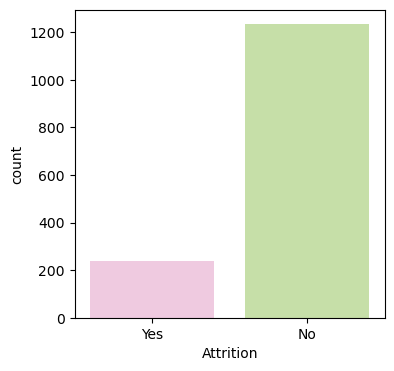

In [7]:
#First, let us check the total number of people who've left.
plt.figure(figsize=(4,4))
sns.countplot(data=df, x='Attrition', hue='Attrition', palette='PiYG')

print(df['Attrition'].value_counts())
plt.show()

In [8]:
# Convert Attrition and OverTime into 1s and 0s
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

# For Gender, let's map Male to 1 and Female to 0 
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [9]:
travel_mapping = {'Non-Travel' : 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df['BusinessTravel'] = df['BusinessTravel'].map(travel_mapping)

In [ ]:

nominal_cols = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [11]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)
print(df.dtypes)

Age                                  int64
Attrition                            int64
BusinessTravel                       int64
DailyRate                            int64
DistanceFromHome                     int64
Education                            int64
EnvironmentSatisfaction              int64
Gender                               int64
HourlyRate                           int64
JobInvolvement                       int64
JobLevel                             int64
JobSatisfaction                      int64
MonthlyIncome                        int64
MonthlyRate                          int64
NumCompaniesWorked                   int64
OverTime                             int64
PercentSalaryHike                    int64
PerformanceRating                    int64
RelationshipSatisfaction             int64
StockOptionLevel                     int64
TotalWorkingYears                    int64
TrainingTimesLastYear                int64
WorkLifeBalance                      int64
YearsAtComp

In [12]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,1102,1,2,2,0,94,3,...,0,0,0,0,0,0,1,0,0,1
1,49,0,2,279,8,1,3,1,61,2,...,0,0,0,0,0,1,0,0,1,0
2,37,1,1,1373,2,2,4,1,92,2,...,0,1,0,0,0,0,0,0,0,1
3,33,0,2,1392,3,4,4,0,56,3,...,0,0,0,0,0,1,0,0,1,0
4,27,0,1,591,2,1,1,1,40,3,...,0,1,0,0,0,0,0,0,1,0


Total Counts:
Attrition
0    1233
1     237
Name: count, dtype: int64

Percentages:
Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64


C:\Users\Ananta\AppData\Local\Temp\ipykernel_11584\3995009662.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette="Set2")


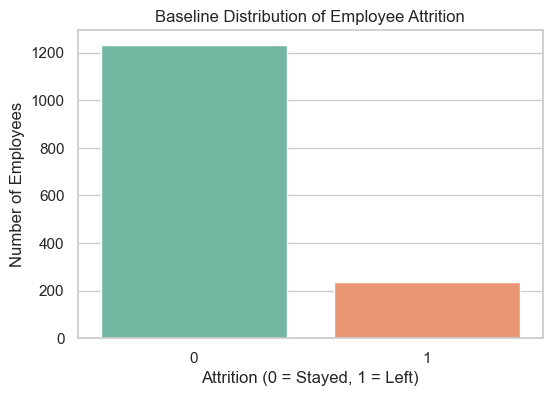

In [13]:
sns.set_theme(style="whitegrid")

# 1. Calculate baseline percentages
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print(f"Total Counts:\n{attrition_counts}\n")
print(f"Percentages:\n{attrition_pct}")

# 2. Plot the baseline
plt.figure(figsize=(6, 4))
sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette="Set2")
plt.title('Baseline Distribution of Employee Attrition')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Employees')
plt.show()

C:\Users\Ananta\AppData\Local\Temp\ipykernel_11584\2412680036.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df, x='OverTime', y='Attrition', errorbar=None, palette='ocean' )
C:\Users\Ananta\AppData\Local\Temp\ipykernel_11584\2412680036.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Overtime (0)', 'Works Overtime (1)'])
C:\Users\Ananta\AppData\Local\Temp\ipykernel_11584\2412680036.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df, x='BusinessTravel', y='Attrition', errorbar=None, palette='magma')
C:\Users\Ananta\AppData\Local\Tem

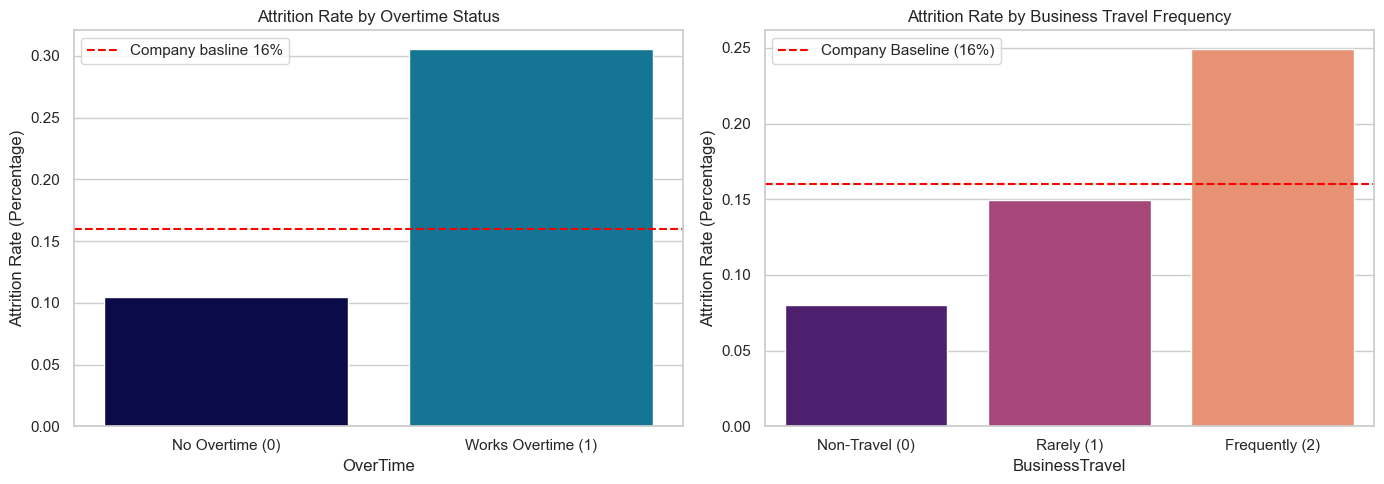

In [14]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
#Overtime V/S Attrition
sns.barplot(ax=axes[0], data=df, x='OverTime', y='Attrition', errorbar=None, palette='ocean' )
axes[0].axhline(y = 0.16, color='red', linestyle='--', label='Company basline 16%')
axes[0].set_title('Attrition Rate by Overtime Status')
axes[0].set_ylabel('Attrition Rate (Percentage)')
axes[0].set_xticklabels(['No Overtime (0)', 'Works Overtime (1)'])
axes[0].legend()
#Business Travel V/S Attrition
sns.barplot(ax=axes[1], data=df, x='BusinessTravel', y='Attrition', errorbar=None, palette='magma')
axes[1].axhline(y=0.16, color='red', linestyle='--', label='Company Baseline (16%)')
axes[1].set_title('Attrition Rate by Business Travel Frequency')
axes[1].set_ylabel('Attrition Rate (Percentage)')
axes[1].set_xticklabels(['Non-Travel (0)', 'Rarely (1)', 'Frequently (2)'])
axes[1].legend()
plt.tight_layout()
plt.show()

C:\Users\Ananta\AppData\Local\Temp\ipykernel_11584\4235615040.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='Attrition', y='MonthlyIncome', palette="Set2")
C:\Users\Ananta\AppData\Local\Temp\ipykernel_11584\4235615040.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Stayed (0)', 'Left (1)'])


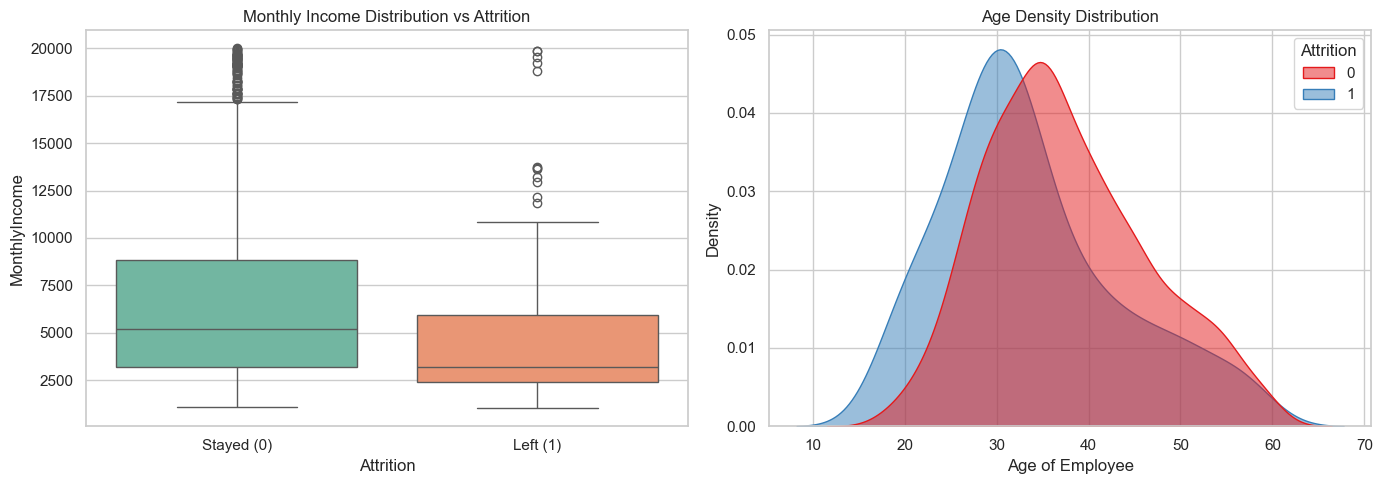

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income and attrtition
sns.boxplot(ax=axes[0], data=df, x='Attrition', y='MonthlyIncome', palette="Set2")
axes[0].set_title('Monthly Income Distribution vs Attrition')
axes[0].set_xticklabels(['Stayed (0)', 'Left (1)'])

# Age vs Attrition
sns.kdeplot(ax=axes[1], data=df, x='Age', hue='Attrition', fill=True, common_norm=False, palette="Set1", alpha=0.5)
axes[1].set_title('Age Density Distribution')
axes[1].set_xlabel('Age of Employee')


plt.tight_layout()
plt.show()

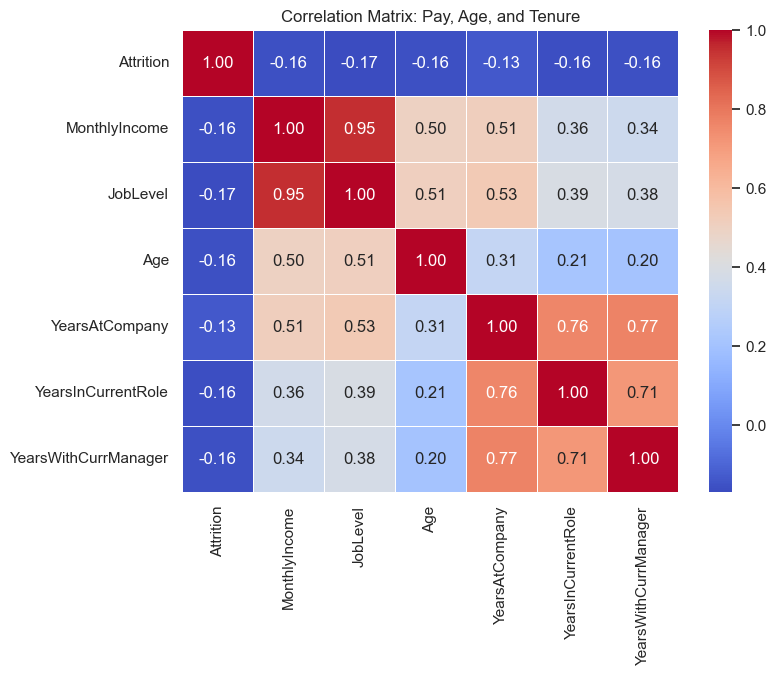

In [16]:
# Checking correlation
time_and_pay_features = [
    'Attrition', 'MonthlyIncome', 'JobLevel', 'Age', 
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager'
]

# Correlation matrix
corr_matrix = df[time_and_pay_features].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Pay, Age, and Tenure')
plt.show()

What We've observed so far:
- About 16% of the employees left.
- Those working overtime have an attrition rate of 30%, almost doublr the company baseline(16%). Overtime is likely causing employee burnout, and is a primary reason employees are leaving.
- Employees who travel more have a higher chance of leaving, compared to those who do not travel at all.
- Most people who leave the company make under $6,000 a month, with the average runner making only around $3,200. On the other hand, employees making high salaries ($15,000+) almost never quit.
- Younger employees have a higher chance of leaving.
- Our correlation heatmap showed that 'JobLevel' and 'MonthlyIncome' are almost perfectly tied together (close to 1.0). We also found that all the time-based metrics (like 'YearsAtCompany' , 'YearsWithCurrManager', 'YearsInCurrentRole') are heavily overlapping.
- Higher income, higher job levels, and longer tenure all correlate with lower attrition (people staying).


In [17]:
X = df.drop(columns=['Attrition', 'JobLevel'])
y = df['Attrition']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
from sklearn.preprocessing import StandardScaler

num_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'TotalWorkingYears', 
            'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']


scaler = StandardScaler()

X_train_scaled = x_train.copy()
X_test_scaled = x_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(x_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(x_test[num_cols])

In [19]:
print(X_train_scaled[num_cols].head())

           Age  MonthlyIncome  DistanceFromHome  TotalWorkingYears  \
1194  1.090194       2.026752         -0.899915           2.261482   
128  -1.634828      -0.864408         -0.899915          -1.072675   
810   0.981193       2.347706         -0.777610           1.492061   
478  -1.307825      -0.956202          0.445433          -0.559727   
491   0.654191      -0.185956         -0.043784          -0.175017   

      YearsAtCompany  YearsInCurrentRole  YearsWithCurrManager  
1194       -0.665706           -0.625365             -0.616406  
128        -0.830071           -0.905635             -0.897047  
810         0.813578            1.336527              1.348076  
478        -0.008246           -0.064824              0.506155  
491         0.156119            0.775986              0.786795  


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
# We are using Logistic Regression, Random Forest, and XGBoost
# Calculate the imbalance ratio for XGBoost
# Total negative cases (0) divided by total positive cases (1)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100, max_depth=4, min_samples_leaf=5)
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=ratio, 
    n_estimators=100,
    max_depth=3,            
    learning_rate=0.05,     
    min_child_weight=3,     
    eval_metric='logloss'
)

In [21]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"================ {name} ================")
    print(f"Overall Accuracy : {acc:.2%}")
    print(f"Recall (Catching flight risks) : {rec:.2%}")
    print(f"F1-Score (Overall balance)     : {f1:.2%}")
    print("\nDetailed Report:")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))
    print("\n")

c:\Users\Ananta\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


================ Logistic Regression ================
Overall Accuracy : 77.55%
Recall (Catching flight risks) : 70.21%
F1-Score (Overall balance)     : 50.00%

Detailed Report:
              precision    recall  f1-score   support

      Stayed       0.93      0.79      0.86       247
        Left       0.39      0.70      0.50        47

    accuracy                           0.78       294
   macro avg       0.66      0.75      0.68       294
weighted avg       0.85      0.78      0.80       294



================ Random Forest ================
Overall Accuracy : 80.61%
Recall (Catching flight risks) : 53.19%
F1-Score (Overall balance)     : 46.73%

Detailed Report:
              precision    recall  f1-score   support

      Stayed       0.91      0.86      0.88       247
        Left       0.42      0.53      0.47        47

    accuracy                           0.81       294
   macro avg       0.66      0.70      0.67       294
weighted avg       0.83      0.81      0.82      

### **Model Evaluation & Final Selection Conclusions**

We trained three classification models—**Logistic Regression, Random Forest, and XGBoost**—to predict employee attrition. Since the dataset is imbalanced (approximately 16% of employees left the company), model evaluation focused not only on **Accuracy** but also on **Recall**, **Precision**, and **F1-Score** for the attrition ("Left") class.

| Model                   |    Accuracy   | Recall (Caught Flight Risks) | Precision (True Signals) | F1-Score (Balance) |
| :---------------------- | :-----------: | :--------------------------: | :----------------------: | :----------------: |
| **Logistic Regression** |     77.55%    |         **70.21%** 🏆        |          39.00%          |    **50.00%** 🏆   |
| **Random Forest**       |     80.61%    |            53.19%            |          42.00%          |       46.73%       |
| **XGBoost**             | **81.63%** 🏆 |            57.45%            |       **44.00%** 🏆      |    **50.00%** 🏆   |

#### **Key Insights & Trade-offs**

**1. Business Context: Why Recall Matters**

In employee attrition prediction, the primary objective is to identify employees who are likely to leave before they resign. Missing an at-risk employee (a false negative) can lead to talent loss, recruitment costs, and reduced organizational productivity. Therefore, **Recall** is a critical metric because it measures how effectively the model identifies actual flight risks.

**2. Logistic Regression Achieved the Highest Recall**

Logistic Regression achieved the highest Recall score (**70.21%**), successfully identifying the majority of employees who eventually left the company. This makes it the most effective model for detecting potential attrition cases. However, its lower Precision (**39.00%**) indicates that it generates more false alarms, meaning some employees flagged as high-risk would ultimately remain with the company.

**3. XGBoost Delivered the Best Overall Performance**

XGBoost achieved the highest overall Accuracy (**81.63%**) and the highest Precision (**44.00%**) while maintaining the same F1-Score (**50.00%**) as Logistic Regression. This indicates a better balance between correctly identifying flight risks and minimizing false positives. Although its Recall (**57.45%**) was lower than Logistic Regression, it still captured more than half of all attrition cases while producing more reliable predictions.

**4. Random Forest Provided Moderate Results**

Random Forest achieved respectable Accuracy (**80.61%**) but underperformed compared to XGBoost across most key metrics. Its Recall (**53.19%**) and F1-Score (**46.73%**) were lower, suggesting that it was less effective at identifying employees at risk of leaving.

#### **Final Decision**

Two models stand out depending on the business objective:

* **If the primary goal is maximizing the detection of at-risk employees**, **Logistic Regression** is the preferred model because it achieved the highest Recall (**70.21%**), successfully identifying the largest proportion of employees who eventually left the company.
* **If the goal is achieving the best overall predictive performance while maintaining a balanced trade-off between Recall and Precision**, **XGBoost** is the preferred model due to its superior Accuracy (**81.63%**), highest Precision (**44.00%**), and equivalent F1-Score (**50.00%**).

For this project, **Logistic Regression is selected as the final model** because the primary business objective is to identify as many employees at risk of attrition as possible. With the highest Recall (**70.21%**), Logistic Regression was the most effective model at detecting employees who eventually left the organization. Although XGBoost achieved higher Accuracy and Precision, the cost of missing at-risk employees was considered more significant than generating additional false positives. Therefore, Logistic Regression was chosen as the most appropriate model for supporting proactive employee retention strategies.


In [22]:
import joblib

#Saving the trained model and scaler to files
joblib.dump(log_reg, 'attrition_model.pkl')
joblib.dump(scaler, 'numerical_scaler.pkl')


['numerical_scaler.pkl']

In [26]:
model_features = list(X_train_scaled.columns)

joblib.dump(model_features, 'model_features.pkl')

['model_features.pkl']

In [23]:
# Print the exact list of columns your model was trained on
print("--- MODEL FEATURES ---")
print(list(log_reg.feature_names_in_))

--- MODEL FEATURES ---
['Age', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [24]:
# Check the exact features your scaler saw during training
if hasattr(scaler, "feature_names_in_"):
    print("Scaler Features:", list(scaler.feature_names_in_))
else:
    print("The scaler doesn't track names. Let's find how many features it expects:")
    print("Number of features expected:", scaler.n_features_in_)

Scaler Features: ['Age', 'MonthlyIncome', 'DistanceFromHome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']


In [27]:
# For numerical constants, find the median:
print(df[['DailyRate', 'HourlyRate', 'MonthlyRate', 'PercentSalaryHike', 'NumCompaniesWorked']].median())

# For survey/ordinal constants, find the most common answer (mode):
print(df[['PerformanceRating', 'RelationshipSatisfaction', 'TrainingTimesLastYear', 'Education']].mode().iloc[0])

DailyRate               802.0
HourlyRate               66.0
MonthlyRate           14235.5
PercentSalaryHike        14.0
NumCompaniesWorked        2.0
dtype: float64
PerformanceRating           3
RelationshipSatisfaction    3
TrainingTimesLastYear       2
Education                   3
Name: 0, dtype: int64
